In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter, defaultdict
import networkx as nx
from datetime import datetime
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load the JSON data
with open('../attack_tree_data/attack_tree_structure_20250913_025539_complete.json', 'r') as f:
    data = json.load(f)

print("Data loaded successfully!")
print(f"Total nodes: {len(data['nodes'])}")
print(f"Total paths: {len(data['paths'])}")
print(f"Node types: {list(data['statistics']['node_type_counts'].keys())}")

Data loaded successfully!
Total nodes: 100
Total paths: 27
Node types: ['root', 'tactic', 'cwe', 'subtech', 'gate', 'capec', 'tech']


In [23]:
# ---- Extract CWE values from paths ----
cwes = []
for path_id, path in data['paths'].items():
    if 'cwe' in path and path['cwe']:  # ensure it exists and is not empty
        cwes.append(str(path['cwe']))

# Count frequencies
cwe_counts = Counter(cwes)

# Print them all
print("\nAll unique CWEs in the dataset:")
for cwe, count in cwe_counts.items():
    print(f"{cwe}: {count}")

print(f"\nTotal unique CWEs: {len(cwe_counts)}")



All unique CWEs in the dataset:
Use of Hard-coded Credentials: 2
Incorrect Permission Assignment for Critical Resource: 12
Improper Authentication: 9
Cleartext Storage of Sensitive Information: 2
Cleartext Transmission of Sensitive Information: 2

Total unique CWEs: 5


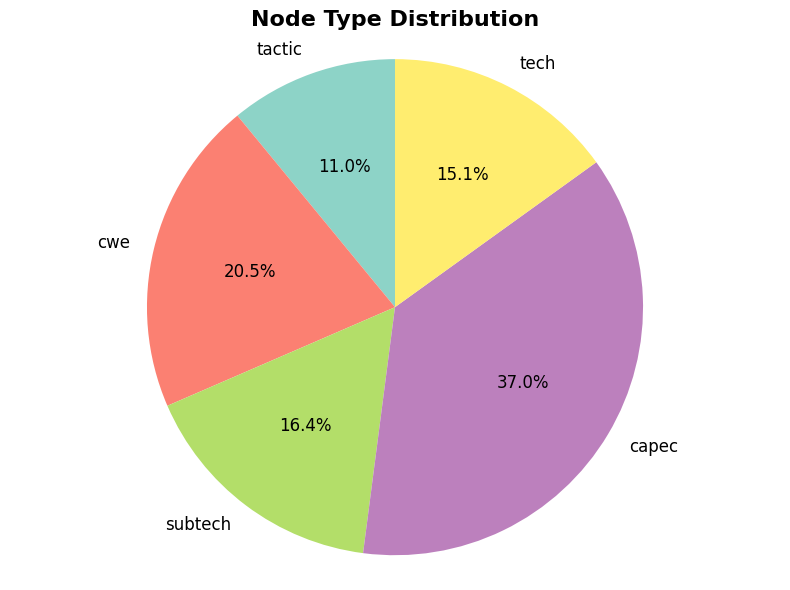

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def create_node_type_distribution():
    node_counts = data['statistics']['node_type_counts']
    
    # Remove "root" and "gate" if present
    filtered_counts = {k: v for k, v in node_counts.items() if k.lower() not in ["root", "gate"]}
    
    plt.figure(figsize=(8, 6))
    
    # Colors for pie chart
    colors = plt.cm.Set3(np.linspace(0, 1, len(filtered_counts)))
    
    # Academic-style pie chart
    wedges, texts, autotexts = plt.pie(
        filtered_counts.values(),
        labels=filtered_counts.keys(),
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 12}
    )
    
    # Title formatting
    plt.title('Node Type Distribution', fontsize=16, fontweight='bold')
    
    # Equal aspect ratio ensures pie is a circle
    plt.axis('equal')
    
    plt.tight_layout()
    plt.savefig('node_type_distribution_pie.png', dpi=300, bbox_inches='tight')
    plt.show()

create_node_type_distribution()


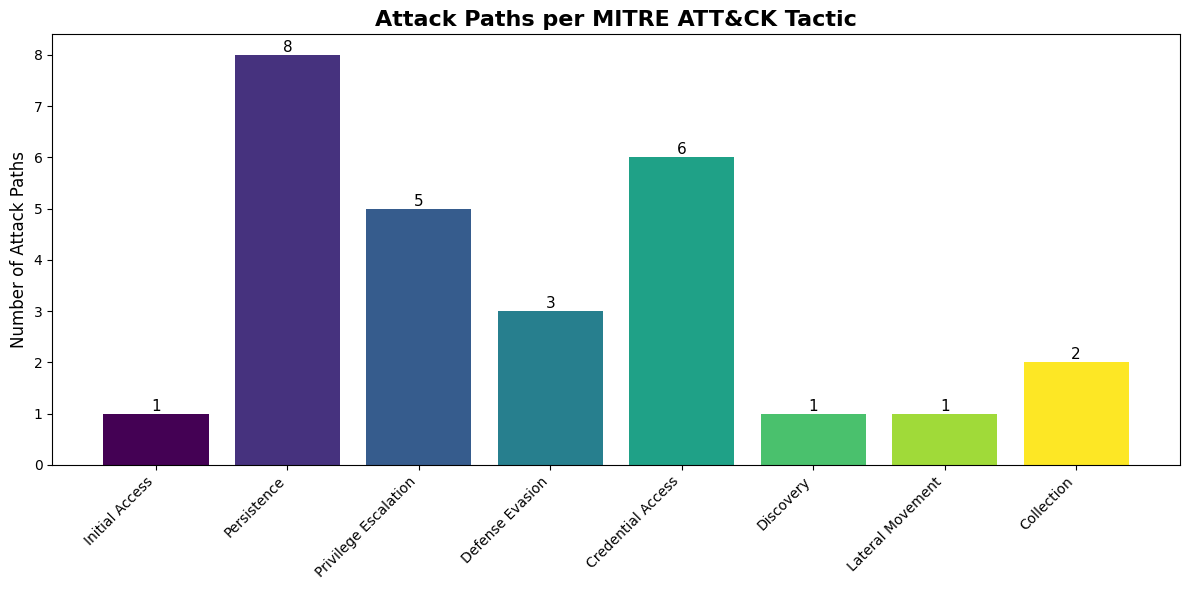

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

def create_tactic_analysis():
    # Extract tactic information
    tactic_data = []
    for node_id, node in data['nodes'].items():
        if node['node_type'] == 'tactic':
            tactic_data.append({
                'tactic': node['label'],
                'order': node['metadata']['mitre_order']
            })
    
    tactic_df = pd.DataFrame(tactic_data).sort_values('order')
    
    # Count paths per tactic
    path_counts = Counter()
    for path in data['paths'].values():
        path_counts[path['tactic']] += 1
    
    tactic_df['path_count'] = tactic_df['tactic'].map(path_counts).fillna(0)
    
    # Plot only the main bar chart
    plt.figure(figsize=(12, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(tactic_df)))
    
    bars = plt.bar(range(len(tactic_df)), tactic_df['path_count'], color=colors)
    
    plt.xticks(range(len(tactic_df)), tactic_df['tactic'], rotation=45, ha='right')
    plt.ylabel('Number of Attack Paths', fontsize=12)
    plt.title('Attack Paths per MITRE ATT&CK Tactic', fontsize=16, fontweight='bold')
    
    # Add count labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('attack_paths_per_tactic.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return tactic_df

tactic_df = create_tactic_analysis()


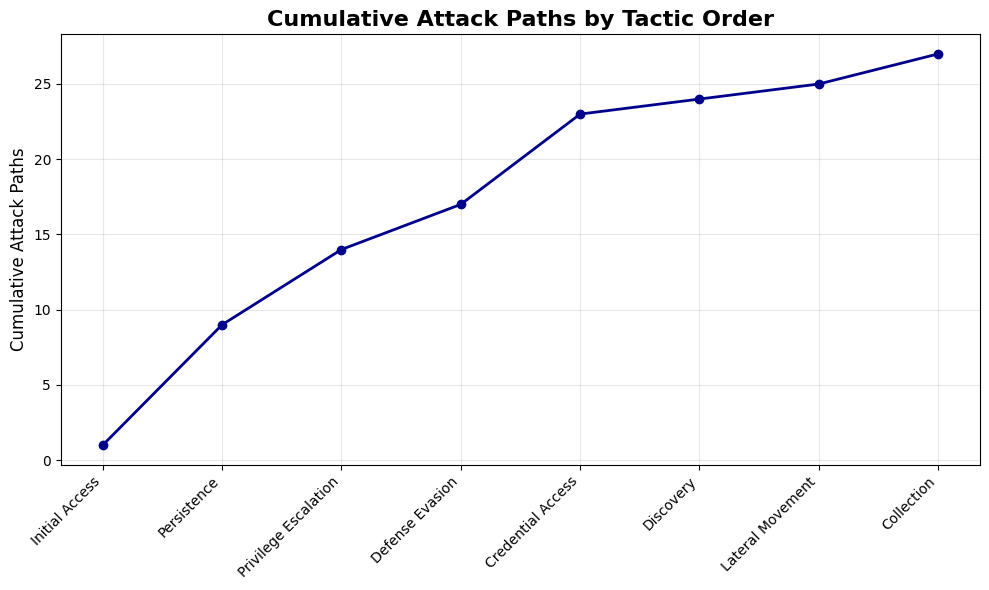

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

def create_cumulative_attack_paths():
    # Extract tactic information
    tactic_data = []
    for node_id, node in data['nodes'].items():
        if node['node_type'] == 'tactic':
            tactic_data.append({
                'tactic': node['label'],
                'order': node['metadata']['mitre_order']
            })
    
    tactic_df = pd.DataFrame(tactic_data).sort_values('order')
    
    # Count paths per tactic
    path_counts = Counter()
    for path in data['paths'].values():
        path_counts[path['tactic']] += 1
    
    tactic_df['path_count'] = tactic_df['tactic'].map(path_counts).fillna(0)
    
    # Compute cumulative counts
    cumulative_counts = np.cumsum(tactic_df['path_count'])
    
    # Plot cumulative attack paths
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(tactic_df)), cumulative_counts, 
             marker='o', linewidth=2, markersize=6, color="darkblue")
    
    plt.xticks(range(len(tactic_df)), tactic_df['tactic'], rotation=45, ha='right')
    plt.ylabel('Cumulative Attack Paths', fontsize=12)
    plt.title('Cumulative Attack Paths by Tactic Order', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cumulative_attack_paths.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return tactic_df, cumulative_counts

tactic_df, cumulative_counts = create_cumulative_attack_paths()


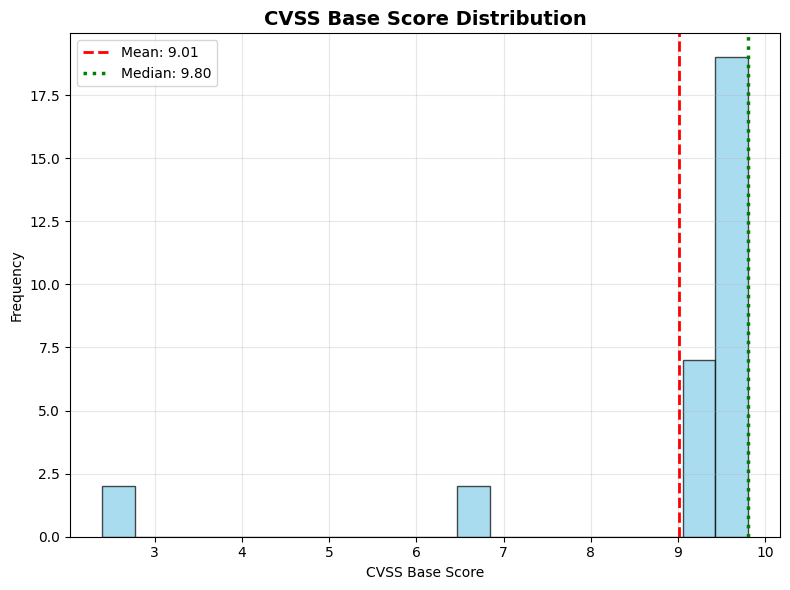

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cvss_distribution(data):
    # Extract CVSS scores
    cvss_scores = []
    for node in data['nodes'].values():
        if 'baseScore' in node['metadata']:
            scores = node['metadata']['baseScore']
            if '|' in str(scores):
                for score in str(scores).split(' | '):
                    try:
                        cvss_scores.append(float(score))
                    except:
                        pass
            else:
                try:
                    cvss_scores.append(float(scores))
                except:
                    pass
    
    # Plot histogram
    plt.figure(figsize=(8, 6))
    plt.hist(cvss_scores, bins=20, color='skyblue', alpha=0.7, edgecolor='black')
    
    # Add mean & median with different line styles
    plt.axvline(np.mean(cvss_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(cvss_scores):.2f}')
    plt.axvline(np.median(cvss_scores), color='green', linestyle=':', linewidth=2.5, label=f'Median: {np.median(cvss_scores):.2f}')
    
    plt.xlabel('CVSS Base Score')
    plt.ylabel('Frequency')
    plt.title('CVSS Base Score Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cvss_score_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# ---- Call function ----
plot_cvss_distribution(data)


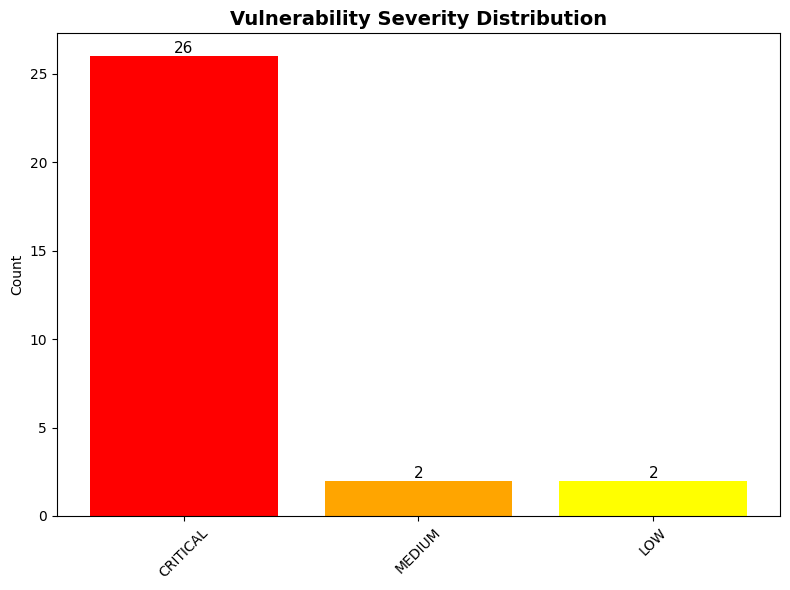

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_severity_distribution(data):
    # Extract severities
    severities = []
    for node in data['nodes'].values():
        if 'baseSeverity' in node['metadata']:
            sev = node['metadata']['baseSeverity']
            if '|' in str(sev):
                severities.extend(str(sev).split(' | '))
            else:
                severities.append(str(sev))
    
    severity_counts = Counter(severities)
    
    # Plot bar chart
    plt.figure(figsize=(8, 6))
    colors = ['red', 'orange', 'yellow', 'green'][:len(severity_counts)]
    bars = plt.bar(severity_counts.keys(), severity_counts.values(), color=colors)
    
    plt.title('Vulnerability Severity Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    # Add count labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('severity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# ---- Call function ----
plot_severity_distribution(data)


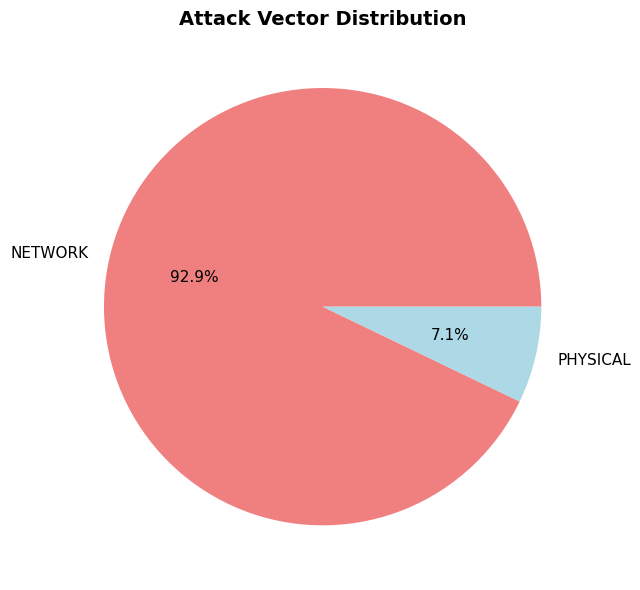

In [11]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_attack_vector_distribution(data):
    # Extract attack vectors
    attack_vectors = []
    for node in data['nodes'].values():
        if 'attackVector' in node['metadata']:
            vec = node['metadata']['attackVector']
            if '|' in str(vec):
                attack_vectors.extend(str(vec).split(' | '))
            else:
                attack_vectors.append(str(vec))
    
    vector_counts = Counter(attack_vectors)
    
    # Plot pie chart
    plt.figure(figsize=(8, 6))
    plt.pie(vector_counts.values(), labels=vector_counts.keys(), autopct='%1.1f%%',
            colors=['lightcoral', 'lightblue', 'lightgreen', 'lightyellow'],
            textprops={'fontsize': 11})
    
    plt.title('Attack Vector Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('attack_vector_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# ---- Call function ----
plot_attack_vector_distribution(data)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter

# ---- Extract path dataframe ----
def get_path_df(data):
    path_data = []
    for path_id, path in data['paths'].items():
        path_data.append({
            'path_id': path_id,
            'cwe': path['cwe'],
            'technique': path['technique'],
            'subtechnique': path['subtechnique'],
            'capec': path['capec'],
            'tactic': path['tactic'],
            'confidence': path['confidence_score'],
            'path_nodes': path['path_nodes']
        })
    return pd.DataFrame(path_data)

# ---- Call once ----
path_df = get_path_df(data)


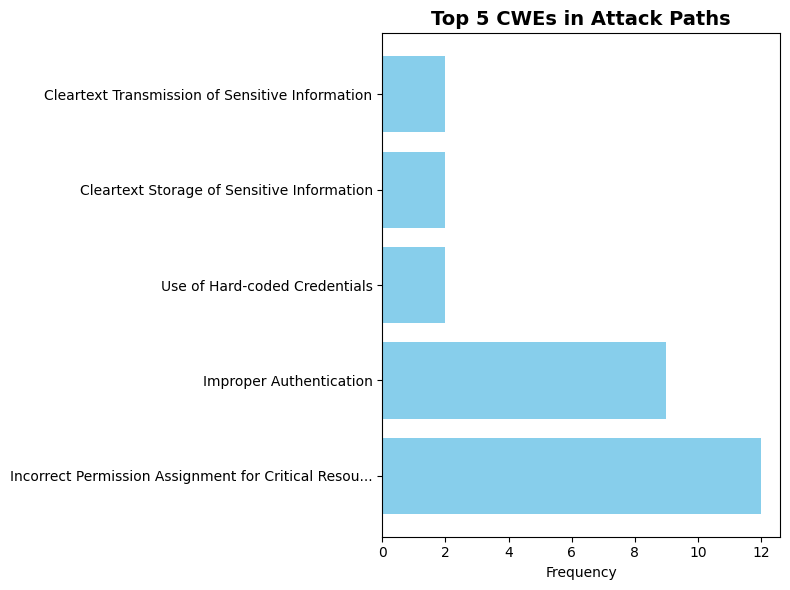

In [22]:
def plot_top_cwes(path_df):
    cwe_counts = Counter(path_df['cwe'])
    top_cwes = dict(cwe_counts.most_common(10))  # request top 10, but might get fewer
    
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(top_cwes)), list(top_cwes.values()), color="skyblue")
    plt.yticks(range(len(top_cwes)), [cwe[:50] + '...' if len(cwe) > 50 else cwe for cwe in top_cwes.keys()])
    plt.xlabel('Frequency')
    
    # Dynamic title
    plt.title(f'Top {len(top_cwes)} CWEs in Attack Paths', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig("top_cwes.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---- Call ----
plot_top_cwes(path_df)


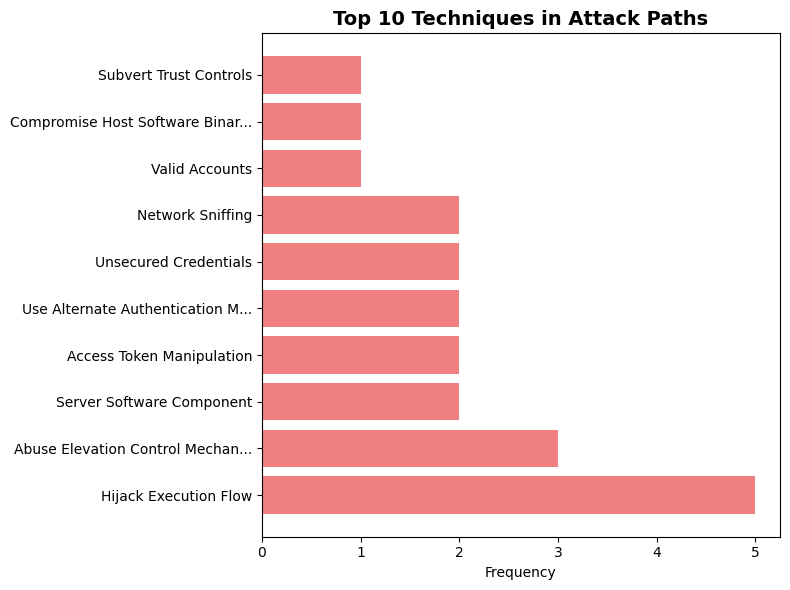

In [15]:
def plot_top_techniques(path_df):
    technique_counts = Counter(path_df['technique'])
    top_techniques = dict(technique_counts.most_common(10))
    
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(top_techniques)), list(top_techniques.values()), color="lightcoral")
    plt.yticks(range(len(top_techniques)), [tech[:30] + '...' if len(tech) > 30 else tech for tech in top_techniques.keys()])
    plt.xlabel('Frequency')
    plt.title('Top 10 Techniques in Attack Paths', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("top_techniques.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---- Call ----
plot_top_techniques(path_df)


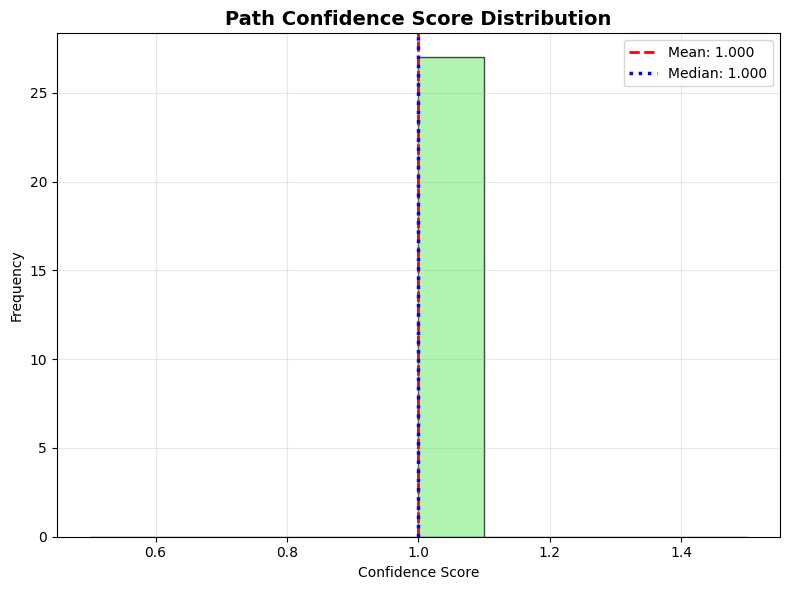

In [16]:
def plot_confidence_distribution(path_df):
    plt.figure(figsize=(8, 6))
    plt.hist(path_df['confidence'], bins=10, color='lightgreen', alpha=0.7, edgecolor='black')
    
    # Mean (dashed) and Median (dotted) for clarity
    plt.axvline(path_df['confidence'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {path_df["confidence"].mean():.3f}')
    plt.axvline(path_df['confidence'].median(), color='blue', linestyle=':', linewidth=2.5, 
                label=f'Median: {path_df["confidence"].median():.3f}')
    
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Path Confidence Score Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("confidence_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---- Call ----
plot_confidence_distribution(path_df)


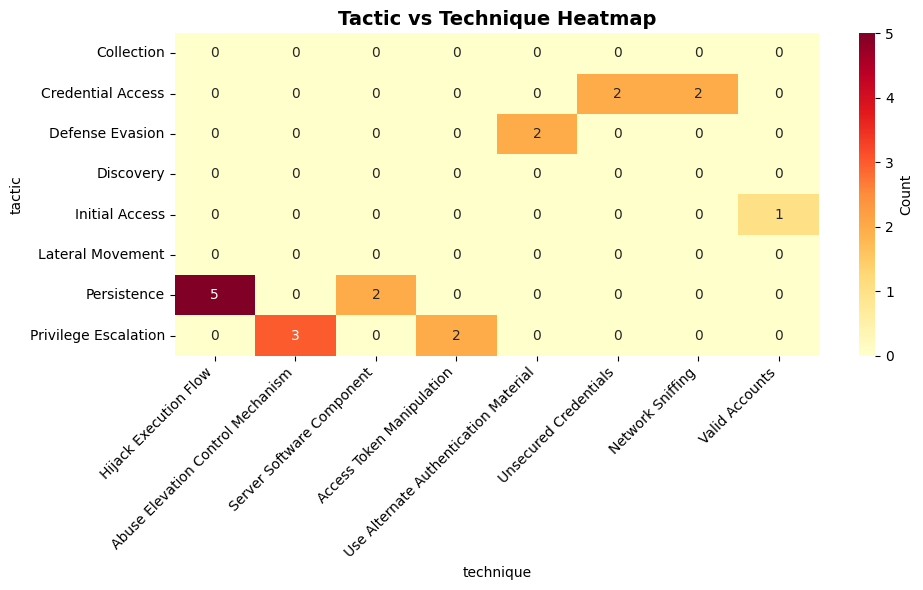

In [17]:
def plot_tactic_vs_technique(path_df):
    technique_counts = Counter(path_df['technique'])
    tactic_tech_matrix = path_df.groupby(['tactic', 'technique']).size().unstack(fill_value=0)
    
    # Limit to top 8 techniques for readability
    top_tech_names = list(technique_counts.most_common(8))
    if len(tactic_tech_matrix.columns) > 8:
        cols_to_show = [tech[0] for tech in top_tech_names if tech[0] in tactic_tech_matrix.columns][:8]
        tactic_tech_matrix = tactic_tech_matrix[cols_to_show]
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(tactic_tech_matrix, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
    plt.title('Tactic vs Technique Heatmap', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("tactic_vs_technique.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---- Call ----
plot_tactic_vs_technique(path_df)


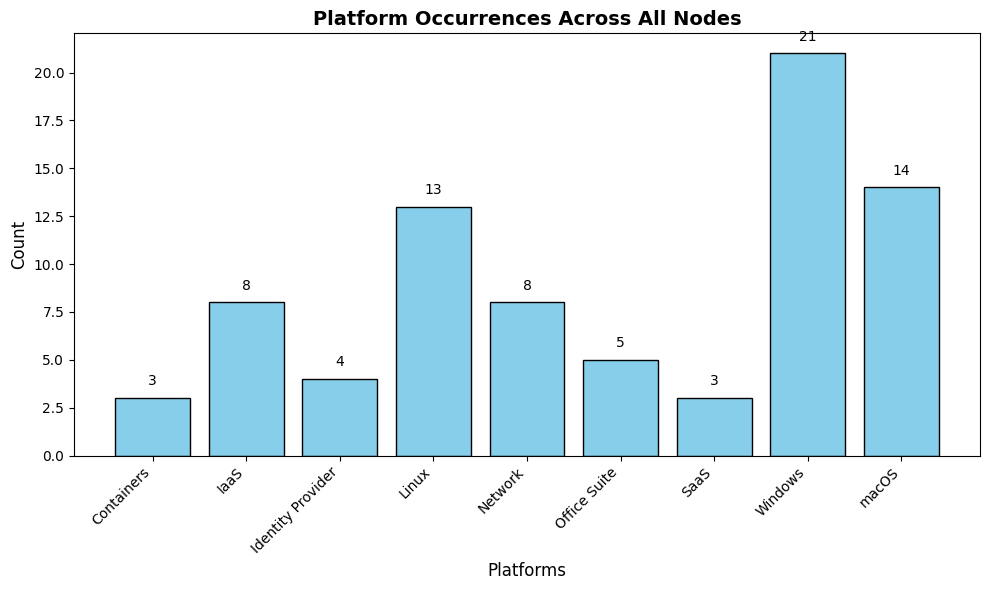

In [25]:
# ---- Extract all platforms ----
platforms = []
for node_id, node in data["nodes"].items():
    if "metadata" in node and "platforms" in node["metadata"]:
        plats = node["metadata"]["platforms"]
        # Split by commas, strip spaces
        for p in plats.split(","):
            p_clean = p.strip()
            if p_clean:  # avoid empty
                platforms.append(p_clean)

# ---- Count frequencies ----
platform_counts = Counter(platforms)

# ---- Plot as bar chart ----
plt.figure(figsize=(10, 6))
bars = plt.bar(platform_counts.keys(), platform_counts.values(), color="skyblue", edgecolor="black")

plt.title("Platform Occurrences Across All Nodes", fontsize=14, fontweight="bold")
plt.xlabel("Platforms", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, str(height), 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("platform_occurrences.png", dpi=300, bbox_inches="tight")
plt.show()

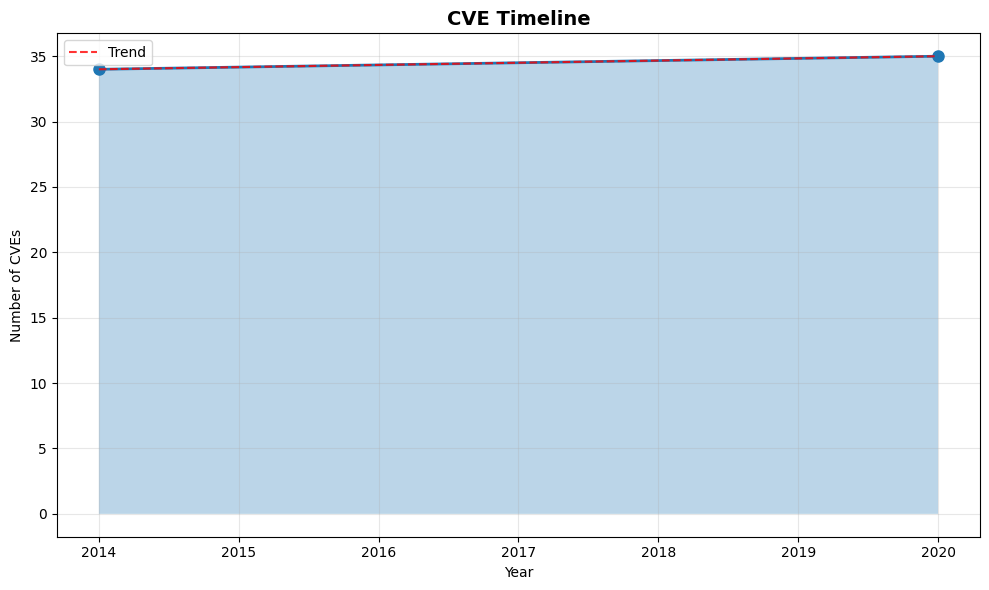

In [26]:
# Prepare CVE timeline data
cve_data = []
for node_id, node in data['nodes'].items():
    if 'CVE ID' in node['metadata']:
        cve_ids = str(node['metadata']['CVE ID']).split(' | ') if '|' in str(node['metadata']['CVE ID']) else [str(node['metadata']['CVE ID'])]
        for cve in cve_ids:
            cve = cve.strip()
            if cve.startswith('CVE-'):
                try:
                    year = int(cve.split('-')[1])
                    cve_data.append(year)
                except:
                    pass

cve_df = pd.DataFrame(cve_data, columns=['year'])

# Plot timeline
if not cve_df.empty:
    cve_year_counts = cve_df['year'].value_counts().sort_index()
    plt.figure(figsize=(10,6))
    plt.plot(cve_year_counts.index, cve_year_counts.values, marker='o', linewidth=2, markersize=8)
    plt.fill_between(cve_year_counts.index, cve_year_counts.values, alpha=0.3)
    
    # Trend line
    z = np.polyfit(cve_year_counts.index, cve_year_counts.values, 1)
    p = np.poly1d(z)
    plt.plot(cve_year_counts.index, p(cve_year_counts.index), "--", alpha=0.8, color='red', label='Trend')
    
    plt.xlabel("Year")
    plt.ylabel("Number of CVEs")
    plt.title("CVE Timeline", fontsize=14, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("cve_timeline.png", dpi=300, bbox_inches="tight")
    plt.show()

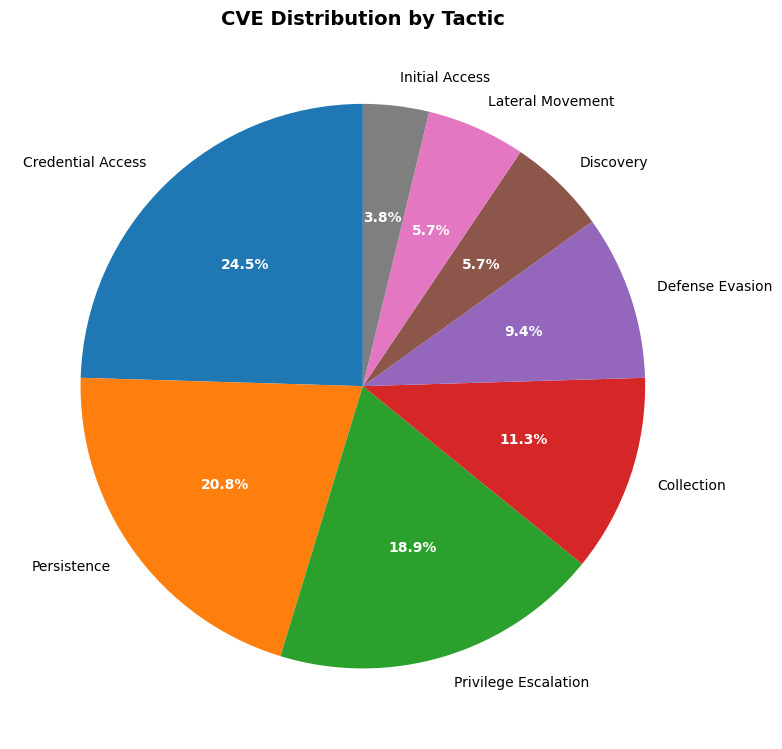

In [27]:
cve_tactic_data = []
for node_id, node in data['nodes'].items():
    if 'CVE ID' in node['metadata']:
        cve_tactic_data.append(node.get('tactic_context', 'Unknown'))

if cve_tactic_data:
    tactic_counts = pd.Series(cve_tactic_data).value_counts()
    plt.figure(figsize=(8,8))
    wedges, texts, autotexts = plt.pie(tactic_counts.values, labels=tactic_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title("CVE Distribution by Tactic", fontsize=14, fontweight="bold")
    
    # Enhance text readability
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.savefig("cve_by_tactic.png", dpi=300, bbox_inches="tight")
    plt.show()


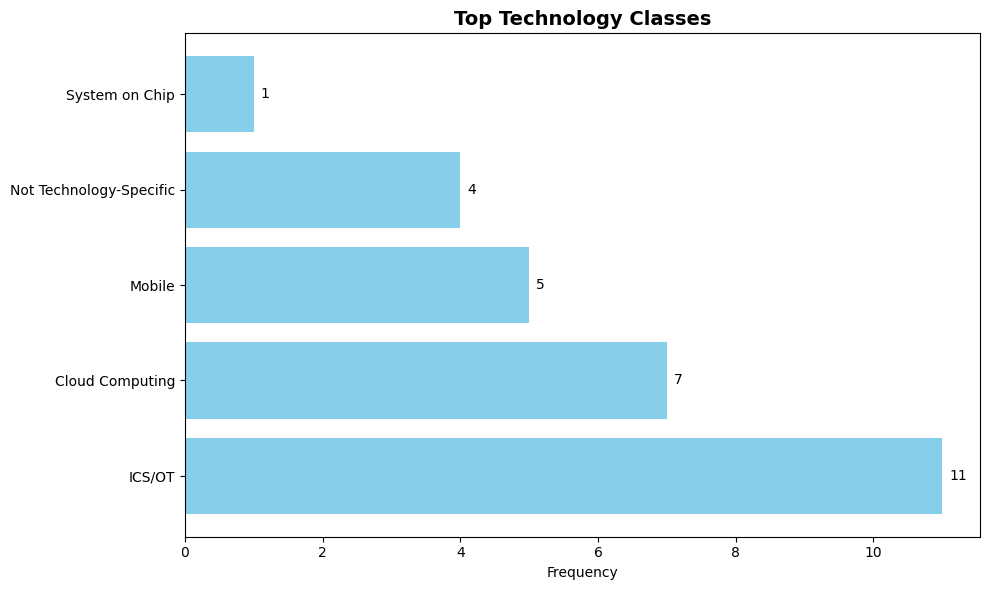

In [28]:
tech_data = []
for node_id, node in data['nodes'].items():
    if 'cwe_Technology_Class' in node['metadata']:
        tech_classes = str(node['metadata']['cwe_Technology_Class']).split(',')
        for t in tech_classes:
            t = t.strip()
            if t not in ['', 'N/A', 'None']:
                tech_data.append(t)

tech_df = pd.Series(tech_data).value_counts()
top_tech = tech_df.head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(range(len(top_tech)), top_tech.values, color='skyblue')
plt.yticks(range(len(top_tech)), top_tech.index)
plt.xlabel("Frequency")
plt.title("Top Technology Classes", fontsize=14, fontweight="bold")

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_tech.values)):
    plt.text(value + 0.1, i, str(value), va='center')

plt.tight_layout()
plt.savefig("top_technology_classes.png", dpi=300, bbox_inches="tight")
plt.show()


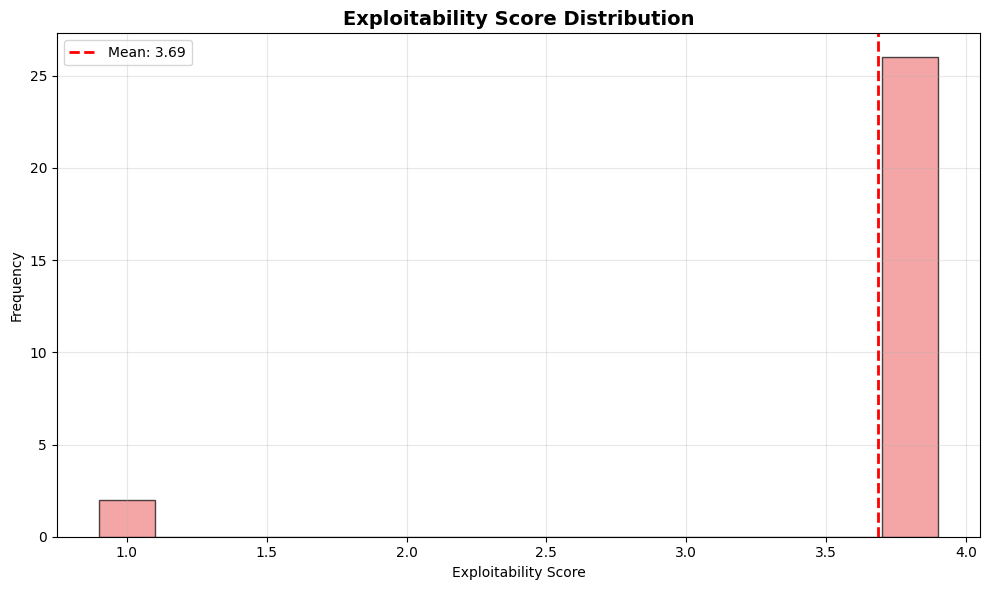

In [29]:
exploit_scores = []
for node in data['nodes'].values():
    if 'exploitabilityScore' in node['metadata']:
        scores = str(node['metadata']['exploitabilityScore']).split(' | ') if '|' in str(node['metadata']['exploitabilityScore']) else [str(node['metadata']['exploitabilityScore'])]
        for s in scores:
            try:
                exploit_scores.append(float(s))
            except:
                pass

if exploit_scores:
    plt.figure(figsize=(10,6))
    plt.hist(exploit_scores, bins=15, alpha=0.7, color='lightcoral', edgecolor='black')
    plt.axvline(np.mean(exploit_scores), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(exploit_scores):.2f}")
    plt.xlabel("Exploitability Score")
    plt.ylabel("Frequency")
    plt.title("Exploitability Score Distribution", fontsize=14, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("exploitability_scores.png", dpi=300, bbox_inches="tight")
    plt.show()


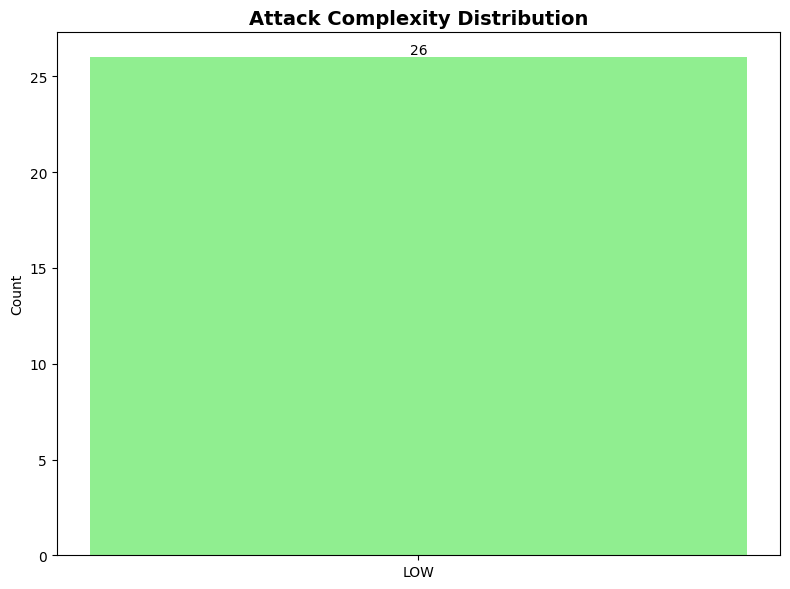

In [30]:
from collections import Counter

attack_complexity = []
for node in data['nodes'].values():
    if 'attackComplexity' in node['metadata']:
        c = node['metadata']['attackComplexity']
        if c not in ['', 'N/A', 'None']:
            attack_complexity.append(str(c))

if attack_complexity:
    complexity_counts = Counter(attack_complexity)
    colors = ['lightgreen' if c == 'LOW' else 'orange' if c == 'MEDIUM' else 'red' for c in complexity_counts.keys()]
    
    plt.figure(figsize=(8,6))
    bars = plt.bar(complexity_counts.keys(), complexity_counts.values(), color=colors)
    plt.ylabel("Count")
    plt.title("Attack Complexity Distribution", fontsize=14, fontweight="bold")
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, str(height), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig("attack_complexity.png", dpi=300, bbox_inches="tight")
    plt.show()


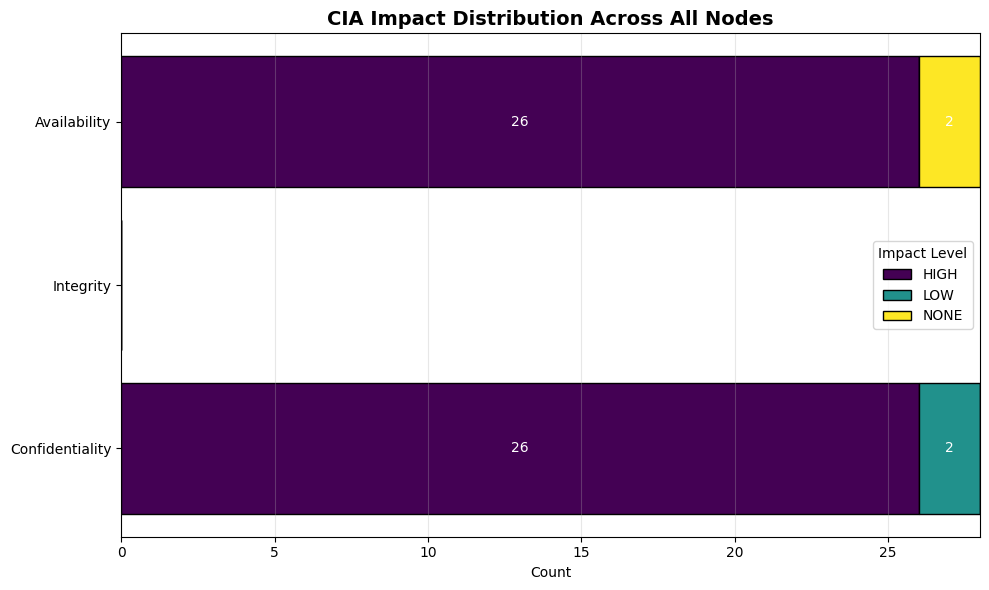

In [45]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# ---- Extract all three impacts, splitting multi-values ----
def extract_impact(field_name):
    values = []
    for node in data['nodes'].values():
        md = node.get('metadata', {})
        if field_name in md:
            for val in str(md[field_name]).split('|'):
                v_clean = val.strip()
                if v_clean:
                    values.append(v_clean)
    return values

confidentiality = extract_impact('confidentialityImpact')
integrity = extract_impact('integrityImpact')
availability = extract_impact('availabilityImpact')

# ---- Count frequencies ----
conf_counts = Counter(confidentiality)
int_counts = Counter(integrity)
avail_counts = Counter(availability)

# ---- Unified levels (HIGH, MEDIUM, LOW, etc.) ----
levels = sorted(set(conf_counts.keys()) | set(int_counts.keys()) | set(avail_counts.keys()))

# ---- Prepare data for stacked bar plot ----
impact_types = ['Confidentiality', 'Integrity', 'Availability']
counts_matrix = []

for counts in [conf_counts, int_counts, avail_counts]:
    counts_matrix.append([counts.get(level, 0) for level in levels])

# Convert to numpy array for easier plotting
counts_matrix = np.array(counts_matrix)

# ---- Plot stacked horizontal bars ----
fig, ax = plt.subplots(figsize=(10,6))

bottom = np.zeros(len(impact_types))

colors = plt.cm.viridis(np.linspace(0,1,len(levels)))

for i, level in enumerate(levels):
    ax.barh(impact_types, counts_matrix[:, i], left=bottom, color=colors[i], edgecolor='black', label=level)
    bottom += counts_matrix[:, i]

# Add value labels inside the bars
for i in range(len(impact_types)):
    cum = 0
    for j in range(len(levels)):
        if counts_matrix[i,j] > 0:
            ax.text(cum + counts_matrix[i,j]/2, i, str(counts_matrix[i,j]), ha='center', va='center', color='white', fontsize=10)
            cum += counts_matrix[i,j]

ax.set_xlabel('Count')
ax.set_title('CIA Impact Distribution Across All Nodes', fontsize=14, fontweight='bold')
ax.legend(title='Impact Level')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("CIA_impact_stacked_horizontal.png", dpi=300, bbox_inches='tight')
plt.show()


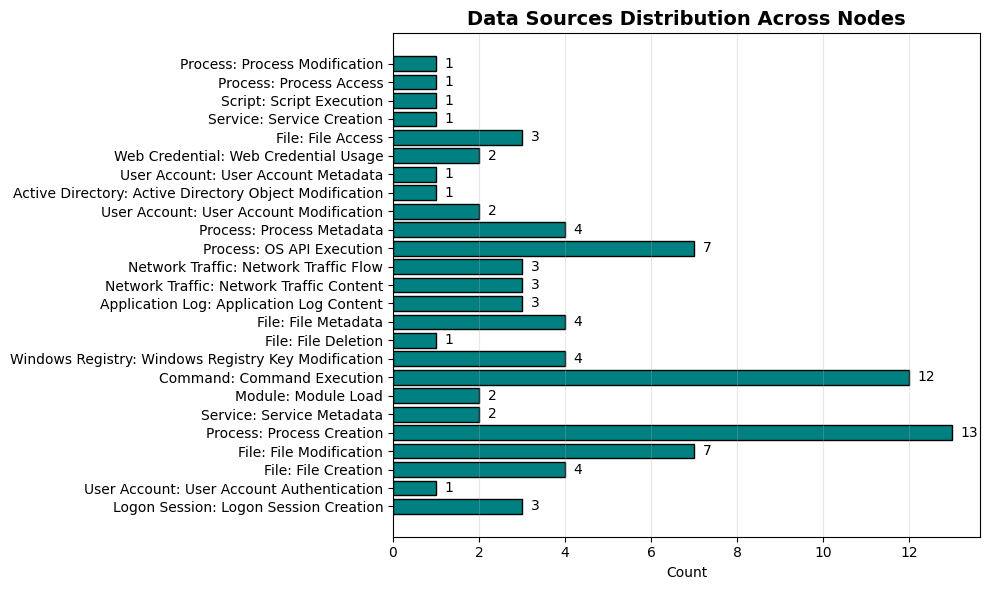

In [46]:
import matplotlib.pyplot as plt
from collections import Counter

# ---- Extract all data sources ----
data_sources = []
for node in data['nodes'].values():
    md = node.get('metadata', {})
    if "data sources" in md:
        for ds in md["data sources"].split(','):
            ds_clean = ds.strip()
            if ds_clean:
                data_sources.append(ds_clean)

# ---- Count frequencies ----
ds_counts = Counter(data_sources)

# ---- Plot horizontal bar chart ----
plt.figure(figsize=(10,6))
bars = plt.barh(list(ds_counts.keys()), list(ds_counts.values()), color='teal', edgecolor='black')
plt.xlabel('Count')
plt.title('Data Sources Distribution Across Nodes', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, str(int(width)), va='center', fontsize=10)

plt.tight_layout()
plt.savefig("data_sources_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


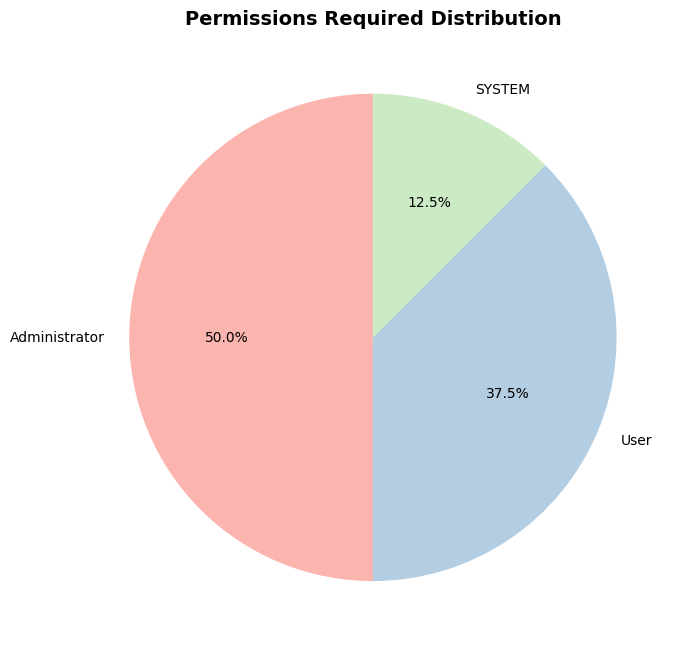

In [47]:
# ---- Extract permissions required ----
permissions = []
for node in data['nodes'].values():
    md = node.get('metadata', {})
    if "permissions required" in md:
        for perm in md["permissions required"].split(','):
            perm_clean = perm.strip()
            if perm_clean:
                permissions.append(perm_clean)

# ---- Count frequencies ----
perm_counts = Counter(permissions)

# ---- Plot pie chart ----
plt.figure(figsize=(7,7))
colors = plt.cm.Pastel1(range(len(perm_counts)))
plt.pie(perm_counts.values(), labels=perm_counts.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Permissions Required Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("permissions_required_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


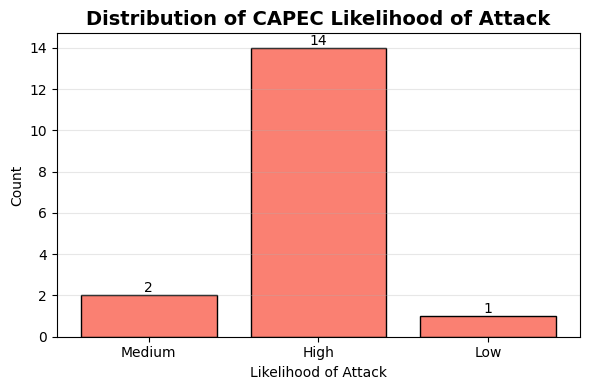

In [50]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract Likelihood of Attack
likelihoods = [node["metadata"]["capec_Likelihood_Of_Attack"] 
               for node in data["nodes"].values() 
               if "capec_Likelihood_Of_Attack" in node.get("metadata", {})]

likelihood_counts = Counter(likelihoods)

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(likelihood_counts.keys(), likelihood_counts.values(), color='salmon', edgecolor='black')
plt.xlabel('Likelihood of Attack')
plt.ylabel('Count')
plt.title('Distribution of CAPEC Likelihood of Attack', fontsize=14, fontweight='bold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(bar.get_height()), ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


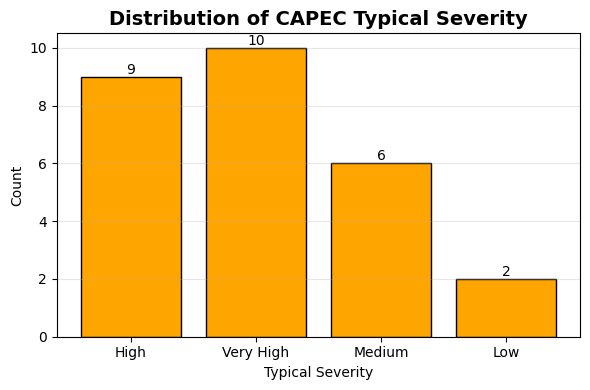

In [51]:
# Extract Typical Severity
severity = [node["metadata"]["capec_Typical_Severity"] 
            for node in data["nodes"].values() 
            if "capec_Typical_Severity" in node.get("metadata", {})]

severity_counts = Counter(severity)

plt.figure(figsize=(6,4))
bars = plt.bar(severity_counts.keys(), severity_counts.values(), color='orange', edgecolor='black')
plt.xlabel('Typical Severity')
plt.ylabel('Count')
plt.title('Distribution of CAPEC Typical Severity', fontsize=14, fontweight='bold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(bar.get_height()), ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


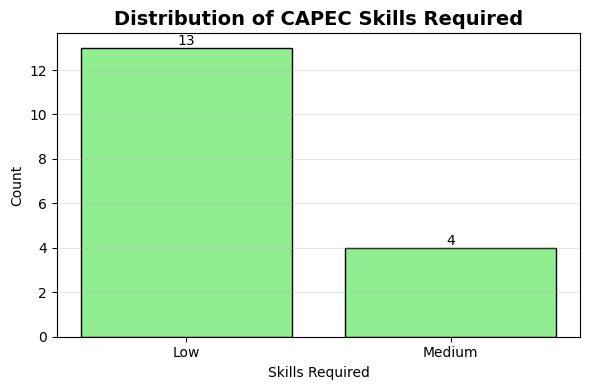

In [56]:


# ---- Extract only skill level keywords ----
skills = []
for node in data["nodes"].values():
    skill_text = node.get("metadata", {}).get("capec_Skills_Required", "")
    if skill_text:
        # Take the keyword before the colon
        key = skill_text.split(":")[0].strip()
        skills.append(key)

# ---- Count frequencies ----
skill_counts = Counter(skills)

# ---- Plot ----
plt.figure(figsize=(6,4))
bars = plt.bar(skill_counts.keys(), skill_counts.values(), color='lightgreen', edgecolor='black')
plt.xlabel('Skills Required')
plt.ylabel('Count')
plt.title('Distribution of CAPEC Skills Required', fontsize=14, fontweight='bold')

# Add value labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())), ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


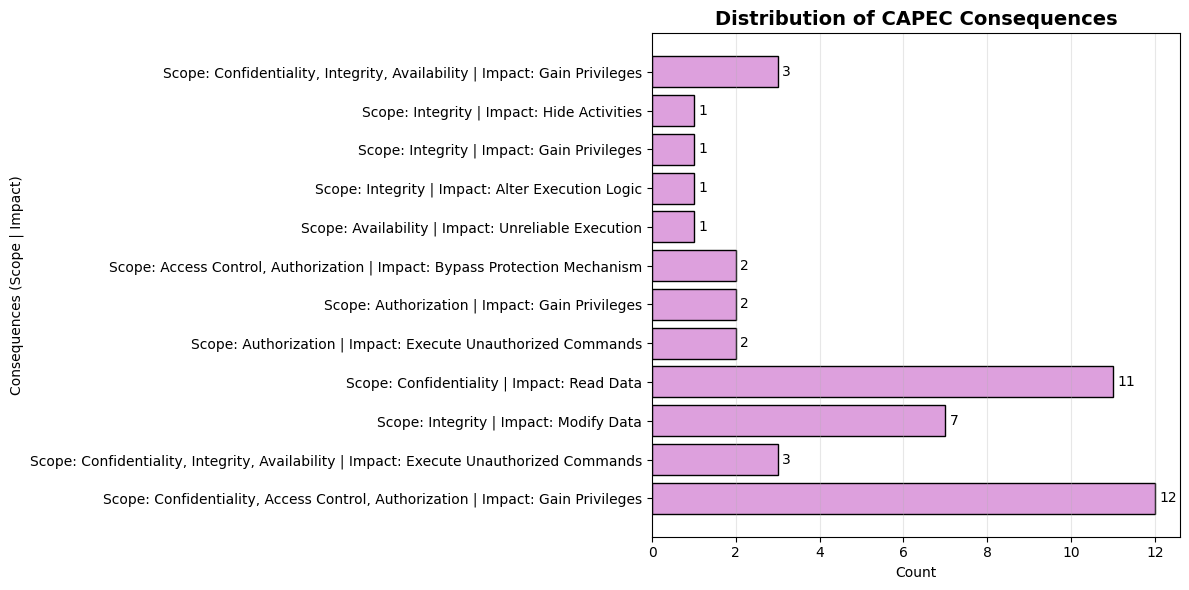

In [55]:
import matplotlib.pyplot as plt
from collections import Counter

# ---- Extract all individual consequences ----
consequences = []
for node in data["nodes"].values():
    cons_text = node.get("metadata", {}).get("capec_Consequences", "")
    # Split each consequence by '||'
    for c in cons_text.split("||"):
        c_clean = c.strip()
        if c_clean:
            consequences.append(c_clean)

# ---- Count frequencies ----
conseq_counts = Counter(consequences)

# ---- Plot ----
plt.figure(figsize=(12,6))
bars = plt.barh(list(conseq_counts.keys()), list(conseq_counts.values()), color='plum', edgecolor='black')
plt.xlabel('Count')
plt.ylabel('Consequences (Scope | Impact)')
plt.title('Distribution of CAPEC Consequences', fontsize=14, fontweight='bold')

# Add value labels on bars
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.1, i, str(int(bar.get_width())), va='center')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
